# Node Extractor V2 — Residual MLP Training

Multi-label image classifier V2: predicts which object categories are present in an image from its SigLIP pooled embedding using a **deep residual MLP** instead of cross-attention.

## Why V2 is better for this input

| | V1 (Cross-Attention) | V2 (Residual MLP) |
|---|---|---|
| Input | 1152-d pooled vector split into fake tokens | 1152-d pooled vector directly |
| Architecture | Q2L-style: 3453 label queries × d_model | 6-block residual MLP, width=2048 |
| Peak VRAM (batch=512) | ~7 GB (OOM at batch=128) | ~0.04 GB activations |
| Batch size | 128 (constrained) | **1024+** (unconstrained) |
| Inductive bias | Cross-attention suited for spatial maps | MLP suited for pooled vectors |

## Pipeline
1. Load vocabulary (built in V1, reused here)
2. Load pre-extracted SigLIP embeddings from HDF5 (built in V1, reused here — **no re-extraction needed**)
3. Create datasets + RFS sampler
4. Train `NodeExtractorMLP` with ASL loss + cosine warmup
5. Evaluate per-class AP and visualise predictions

---
## 1. Setup & Configuration

In [4]:
import sys
import os
import time
import random
from pathlib import Path
from dataclasses import dataclass

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "poc_scripts"))

# ── Configuration ─────────────────────────────────────────────────────────

@dataclass
class Config:
    # Paths — reuse V1 embeddings and vocabulary, new checkpoint name
    train_jsonl: str = str(PROJECT_ROOT / "data" / "merged" / "train.jsonl")
    val_jsonl:   str = str(PROJECT_ROOT / "data" / "merged" / "val.jsonl")
    train_cache: str = str(PROJECT_ROOT / "data" / "merged" / "train_embeddings.h5")
    val_cache:   str = str(PROJECT_ROOT / "data" / "merged" / "val_embeddings.h5")
    vocab_path:  str = str(PROJECT_ROOT / "data" / "merged" / "node_vocab.json")
    checkpoint_dir: str = str(PROJECT_ROOT / "data" / "merged" / "checkpoints")
    checkpoint_name: str = "best_model_v2.pt"   # does NOT overwrite V1

    # Vocabulary
    min_label_freq: int = 50

    # Model V2 — Residual MLP
    input_dim:    int = 1152   # SigLIP SO400M pooled embedding dim
    hidden_dim:   int = 2048   # MLP width (was constrained to 256 in V1 due to VRAM)
    num_blocks:   int = 6      # residual blocks
    expansion:    int = 2      # inner-layer expansion within each block
    dropout:      float = 0.1
    input_dropout: float = 0.05  # regularise raw SigLIP features

    # Loss (same ASL as V1)
    gamma_neg:      float = 4.0
    gamma_pos:      float = 1.0
    clip:           float = 0.05
    label_smoothing: float = 0.05

    # Training — large batch is now safe since MLP activations are tiny
    batch_size:       int = 512
    eval_batch_size:  int = 1024
    lr:               float = 1e-3
    weight_decay:     float = 0.01
    epochs:           int = 500
    warmup_ratio:     float = 0.05
    grad_clip:        float = 1.0
    patience:         int = 10
    num_workers:      int = 8
    eval_threshold:   float = 0.5
    use_amp:          bool = True
    compile_model:    bool = False  # set True for extra speed on Ampere+

cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU:        {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {gpu_props.total_memory / 1024**3:.1f} GB")
    print(f"VRAM free:  {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

os.makedirs(cfg.checkpoint_dir, exist_ok=True)
best_path = os.path.join(cfg.checkpoint_dir, cfg.checkpoint_name)
print(f"\nCheckpoint: {best_path}")
print(f"Batch size: {cfg.batch_size}  |  hidden_dim: {cfg.hidden_dim}  |  blocks: {cfg.num_blocks}")

Device: cuda
GPU:        NVIDIA GeForce RTX 5090
VRAM total: 31.3 GB
VRAM free:  26.1 GB

Checkpoint: /home/shaswata/Desktop/NeSy_KR/data/merged/checkpoints/best_model_v2.pt
Batch size: 512  |  hidden_dim: 2048  |  blocks: 6


---
## 2. Load Vocabulary & Datasets

Reuses the vocabulary and HDF5 embedding cache built by V1 — no re-extraction needed.

In [2]:
from node_extractor_from_latent.dataset import NodeVocabulary, NodeDataset, RepeatFactorSampler
from torch.utils.data import DataLoader

# Load vocabulary (must have been built by V1 first)
assert Path(cfg.vocab_path).exists(), (
    f"Vocabulary not found at {cfg.vocab_path}. "
    "Run train.ipynb (V1) first to build it."
)
vocab = NodeVocabulary()
vocab.load(cfg.vocab_path)

# Load datasets (reads targets from JSONL + embeddings from HDF5)
train_ds = NodeDataset(cfg.train_jsonl, vocab, cfg.train_cache)
val_ds   = NodeDataset(cfg.val_jsonl,   vocab, cfg.val_cache)

# Repeat Factor Sampler for long-tail label balance
rfs = RepeatFactorSampler(train_ds, vocab)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size,
    sampler=rfs,
    num_workers=cfg.num_workers, pin_memory=True,
    drop_last=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.eval_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True,
    persistent_workers=True,
)

emb, target = next(iter(train_loader))
print(f"Train batch  : {emb.shape}   (batch={cfg.batch_size})")
print(f"Target shape : {target.shape}  (vocab={vocab.size})")
print(f"Avg pos/sample: {target.sum(dim=1).mean():.1f}")
print(f"Steps/epoch (RFS): {len(train_loader):,}")
print(f"Val batches  : {len(val_loader)}")

Vocabulary loaded from /home/shaswata/Desktop/NeSy_KR/data/merged/node_vocab.json (3453 labels)
Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/train.jsonl...
  Samples: 183,019
  Vocab size: 3453
  Avg labels per sample: 15.3
  Classes with >0 samples: 3453
Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/val.jsonl...
  Samples: 10,696
  Vocab size: 3453
  Avg labels per sample: 11.7
  Classes with >0 samples: 1283
  RepeatFactorSampler:
    threshold (t)      : 0.000678
    images oversampled : 67,273 / 183,019 (36.8%)
    max repeat factor  : 7.87
    effective epoch size: ~252,041 (was 183,019, 1.38x)
Train batch  : torch.Size([512, 1152])   (batch=512)
Target shape : torch.Size([512, 3453])  (vocab=3453)
Avg pos/sample: 16.2
Steps/epoch (RFS): 492
Val batches  : 11


---
## 3. Initialize Model V2

In [3]:
from node_extractor_from_latent.model_v2 import NodeExtractorMLP

model = NodeExtractorMLP(
    input_dim=cfg.input_dim,
    vocab_size=vocab.size,
    hidden_dim=cfg.hidden_dim,
    num_blocks=cfg.num_blocks,
    expansion=cfg.expansion,
    dropout=cfg.dropout,
    input_dropout=cfg.input_dropout,
).to(device)

param_counts = model.count_parameters()
print("Parameter counts (V2 Residual MLP):")
for name, count in param_counts.items():
    print(f"  {name:12s}: {count:>12,d}")

# Compare to V1 cross-attention model in memory terms
param_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
# Activation memory per batch: B × hidden_dim × 4 bytes (much smaller than V1)
act_mb_est = (cfg.batch_size * cfg.hidden_dim * 4 * cfg.num_blocks * 3) / 1024**2
print(f"\nModel params : ~{param_mb:.0f} MB")
print(f"Activation estimate: ~{act_mb_est:.0f} MB  "
      f"(V1 was ~{cfg.batch_size * 3453 * 256 * 4 * 2 / 1024**2:.0f} MB per layer)")

if cfg.compile_model and device == "cuda":
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("\ntorch.compile enabled")
    except Exception as e:
        print(f"\ntorch.compile failed (non-fatal): {e}")

if device == "cuda":
    print(f"\nGPU memory after model load: "
          f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated")

Parameter counts (V2 Residual MLP):
  input_proj  :    2,365,440
  blocks      :  100,724,736
  head_norm   :        4,096
  head        :    7,075,197
  total       :  110,169,469

Model params : ~420 MB
Activation estimate: ~72 MB  (V1 was ~3453 MB per layer)

GPU memory after model load: 0.41 GB allocated


---
## 4. Loss, Optimizer & Scheduler

In [5]:
from node_extractor_from_latent.utils import (
    AsymmetricLoss, compute_metrics, CosineWarmupScheduler, EarlyStopping,
)

criterion = AsymmetricLoss(
    gamma_neg=cfg.gamma_neg, gamma_pos=cfg.gamma_pos,
    clip=cfg.clip, label_smoothing=cfg.label_smoothing,
)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
)

total_steps  = len(train_loader) * cfg.epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler    = CosineWarmupScheduler(optimizer, warmup_steps, total_steps)
early_stopping = EarlyStopping(patience=cfg.patience, mode="max")

print(f"Total steps  : {total_steps:,}")
print(f"Warmup steps : {warmup_steps:,}")
print(f"Steps/epoch  : {len(train_loader):,}")

Total steps  : 246,000
Warmup steps : 12,300
Steps/epoch  : 492


---
## 5. Training Loop with Live Visualization

In [6]:
scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, n = 0.0, 0
    for emb, target in loader:
        emb    = emb.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            loss = criterion(model(emb), target)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
        n += 1
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_targets = [], []
    for emb, target in loader:
        emb    = emb.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            logits = model(emb)
            loss   = criterion(logits, target)
        total_loss += loss.item(); n += 1
        all_logits.append(logits.float().cpu())
        all_targets.append(target.cpu())
    metrics = compute_metrics(
        torch.cat(all_logits), torch.cat(all_targets), threshold
    )
    metrics["loss"] = total_loss / n
    return metrics


print("Train/eval functions ready.")

Train/eval functions ready.


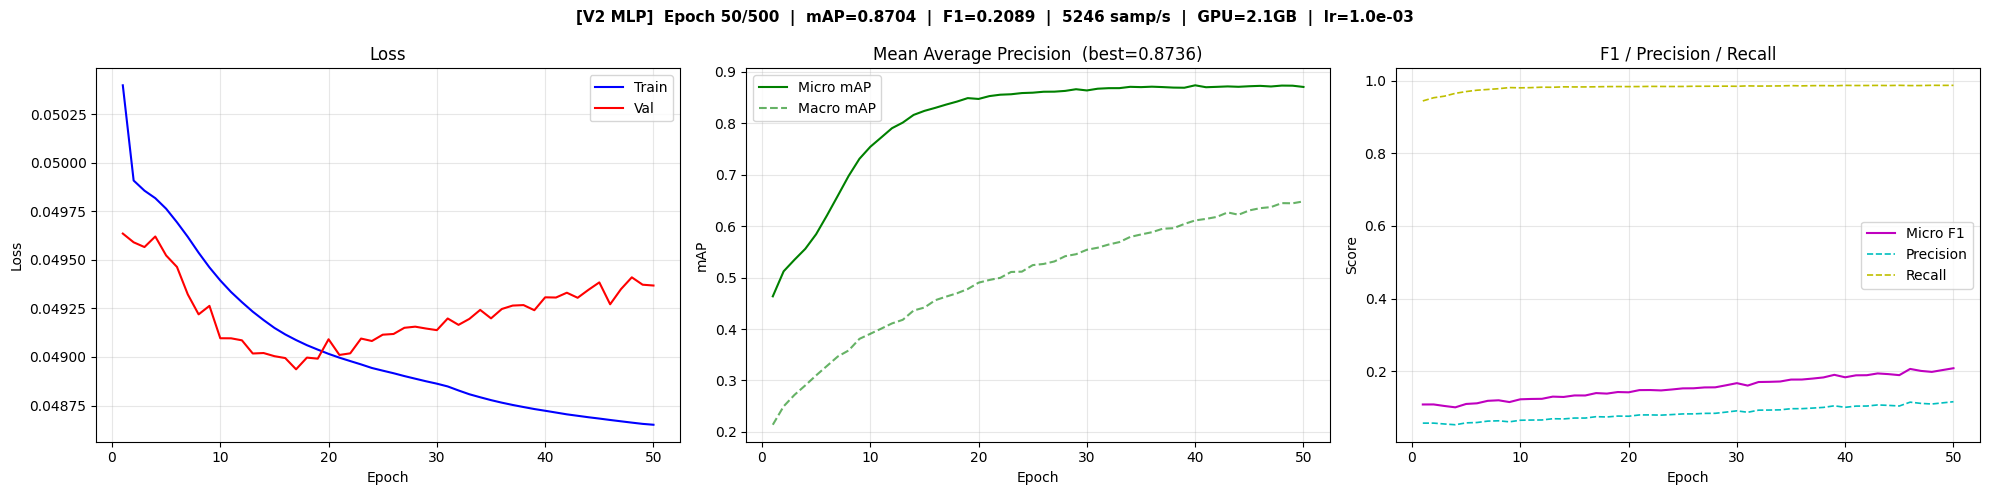


Early stopping at epoch 50. Best mAP=0.8736 at epoch 40

  V2 Training complete
  Best mAP       : 0.8736
  Avg epoch time : 49.9s
  Avg throughput : 5051 samples/s
  Peak GPU mem   : 2.1 GB
  Checkpoint     : /home/shaswata/Desktop/NeSy_KR/data/merged/checkpoints/best_model_v2.pt


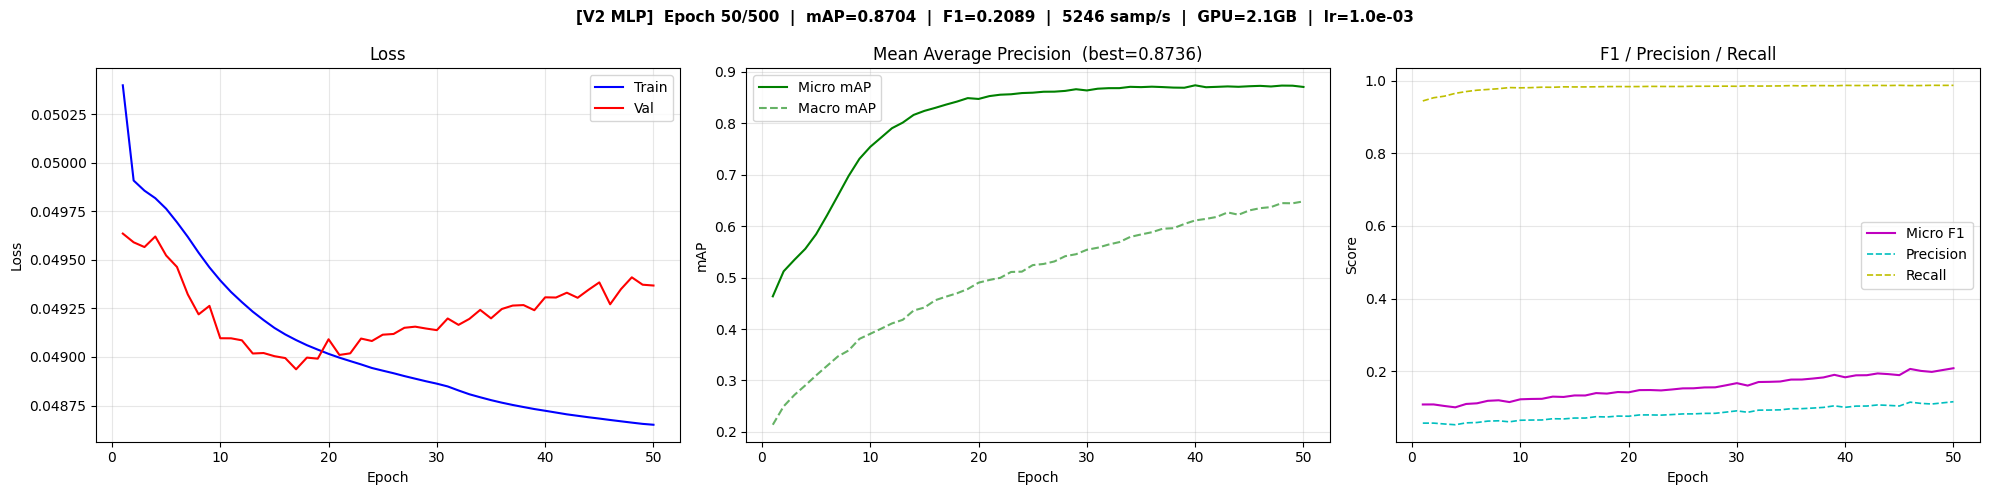

In [7]:
history = {k: [] for k in [
    "train_loss", "val_loss",
    "mAP", "macro_mAP",
    "micro_f1", "macro_f1",
    "micro_precision", "micro_recall",
    "lr", "gpu_mem_gb", "epoch_time",
]}

best_map = 0.0
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.ion()

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    rfs.set_epoch(epoch)

    train_loss  = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    val_metrics = evaluate(model, val_loader, criterion, device, cfg.eval_threshold)

    elapsed  = time.time() - t0
    gpu_mem  = torch.cuda.max_memory_allocated() / 1024**3 if device == "cuda" else 0
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["mAP"].append(val_metrics["mAP"])
    history["macro_mAP"].append(val_metrics["macro_mAP"])
    history["micro_f1"].append(val_metrics["micro_f1"])
    history["macro_f1"].append(val_metrics["macro_f1"])
    history["micro_precision"].append(val_metrics["micro_precision"])
    history["micro_recall"].append(val_metrics["micro_recall"])
    history["lr"].append(current_lr)
    history["gpu_mem_gb"].append(gpu_mem)
    history["epoch_time"].append(elapsed)

    samples_per_sec = len(rfs) / elapsed

    if val_metrics["mAP"] > best_map:
        best_map = val_metrics["mAP"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "mAP": best_map,
            "config": cfg,
            "version": "v2",
        }, best_path)

    # ── Live chart ────────────────────────────────────────────────────
    clear_output(wait=True)
    for ax in axes:
        ax.clear()
    ex = range(1, epoch + 1)

    axes[0].plot(ex, history["train_loss"], "b-", label="Train", linewidth=1.5)
    axes[0].plot(ex, history["val_loss"],   "r-", label="Val",   linewidth=1.5)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ex, history["mAP"],       "g-",  label="Micro mAP", linewidth=1.5)
    axes[1].plot(ex, history["macro_mAP"], "g--", label="Macro mAP", linewidth=1.5, alpha=0.6)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP")
    axes[1].set_title(f"Mean Average Precision  (best={best_map:.4f})")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(ex, history["micro_f1"],        "m-",  label="Micro F1",  linewidth=1.5)
    axes[2].plot(ex, history["micro_precision"],  "c--", label="Precision", linewidth=1.2)
    axes[2].plot(ex, history["micro_recall"],     "y--", label="Recall",    linewidth=1.2)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score")
    axes[2].set_title("F1 / Precision / Recall")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    is_best = " ★" if val_metrics["mAP"] >= best_map else ""
    fig.suptitle(
        f"[V2 MLP]  Epoch {epoch}/{cfg.epochs}  |  "
        f"mAP={val_metrics['mAP']:.4f}{is_best}  |  "
        f"F1={val_metrics['micro_f1']:.4f}  |  "
        f"{samples_per_sec:.0f} samp/s  |  "
        f"GPU={gpu_mem:.1f}GB  |  "
        f"lr={current_lr:.1e}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    display(fig)

    if early_stopping(val_metrics["mAP"], epoch):
        print(f"\nEarly stopping at epoch {epoch}. "
              f"Best mAP={best_map:.4f} at epoch {early_stopping.best_epoch}")
        break

plt.ioff()

avg_time       = np.mean(history["epoch_time"])
avg_throughput = len(rfs) / avg_time
print(f"\n{'='*60}")
print(f"  V2 Training complete")
print(f"{'='*60}")
print(f"  Best mAP       : {best_map:.4f}")
print(f"  Avg epoch time : {avg_time:.1f}s")
print(f"  Avg throughput : {avg_throughput:.0f} samples/s")
print(f"  Peak GPU mem   : {max(history['gpu_mem_gb']):.1f} GB")
print(f"  Checkpoint     : {best_path}")

---
## 6. Evaluation — Per-class AP Analysis

Loaded best_model_v2.pt  — epoch 40, mAP=0.8736

  TOP 20  (by AP)
  Rank                   Label        AP   Support
     1                    kiwi    1.0000         1
     2                 pigeons    1.0000         2
     3                crackers    1.0000         1
     4                tortilla    1.0000         3
     5                   sushi    1.0000         2
     6                    tofu    1.0000         2
     7                    mall    1.0000         3
     8               beverages    1.0000         2
     9            sweet potato    1.0000         1
    10               pineapple    1.0000        15
    11                flamingo    1.0000         2
    12                   moose    1.0000         1
    13                   pecan    1.0000         1
    14                students    1.0000         1
    15               pepperoni    1.0000        25
    16                 ramekin    1.0000         1
    17              cheesecake    1.0000         1
    18         

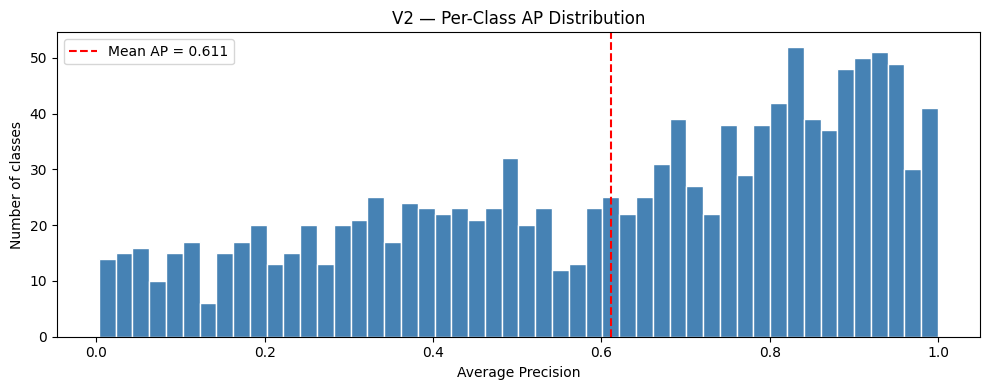

In [8]:
from sklearn.metrics import average_precision_score

checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best_model_v2.pt  — epoch {checkpoint['epoch']}, mAP={checkpoint['mAP']:.4f}")

model.eval()
all_logits, all_targets = [], []
with torch.no_grad():
    for emb, target in val_loader:
        all_logits.append(model(emb.to(device)).cpu())
        all_targets.append(target)

all_logits  = torch.cat(all_logits)
all_targets = torch.cat(all_targets)
all_probs   = torch.sigmoid(all_logits).numpy()
all_tgts_np = all_targets.numpy()

has_pos = all_tgts_np.sum(axis=0) > 0
per_class_ap = np.zeros(vocab.size)
for i in range(vocab.size):
    if has_pos[i]:
        per_class_ap[i] = average_precision_score(all_tgts_np[:, i], all_probs[:, i])

sorted_idx = np.argsort(per_class_ap)[::-1]

print(f"\n{'='*65}")
print(f"  TOP 20  (by AP)")
print(f"{'='*65}")
print(f"  {'Rank':>4}  {'Label':>22}  {'AP':>8}  {'Support':>8}")
for rank, idx in enumerate(sorted_idx[:20]):
    print(f"  {rank+1:4d}  {vocab.idx_to_label[idx]:>22s}  "
          f"{per_class_ap[idx]:8.4f}  {int(all_tgts_np[:, idx].sum()):8d}")

print(f"\n{'='*65}")
print(f"  BOTTOM 20  (by AP, support > 0)")
print(f"{'='*65}")
for rank, idx in enumerate([i for i in sorted_idx[::-1] if has_pos[i]][:20]):
    print(f"  {rank+1:4d}  {vocab.idx_to_label[idx]:>22s}  "
          f"{per_class_ap[idx]:8.4f}  {int(all_tgts_np[:, idx].sum()):8d}")

valid_aps = per_class_ap[has_pos]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_aps, bins=50, color="steelblue", edgecolor="white")
ax.axvline(valid_aps.mean(), color="red", linestyle="--",
           label=f"Mean AP = {valid_aps.mean():.3f}")
ax.set_xlabel("Average Precision")
ax.set_ylabel("Number of classes")
ax.set_title("V2 — Per-Class AP Distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Inference Demo — Prediction Visualization

/tmp/ipykernel_3175400/2432700065.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


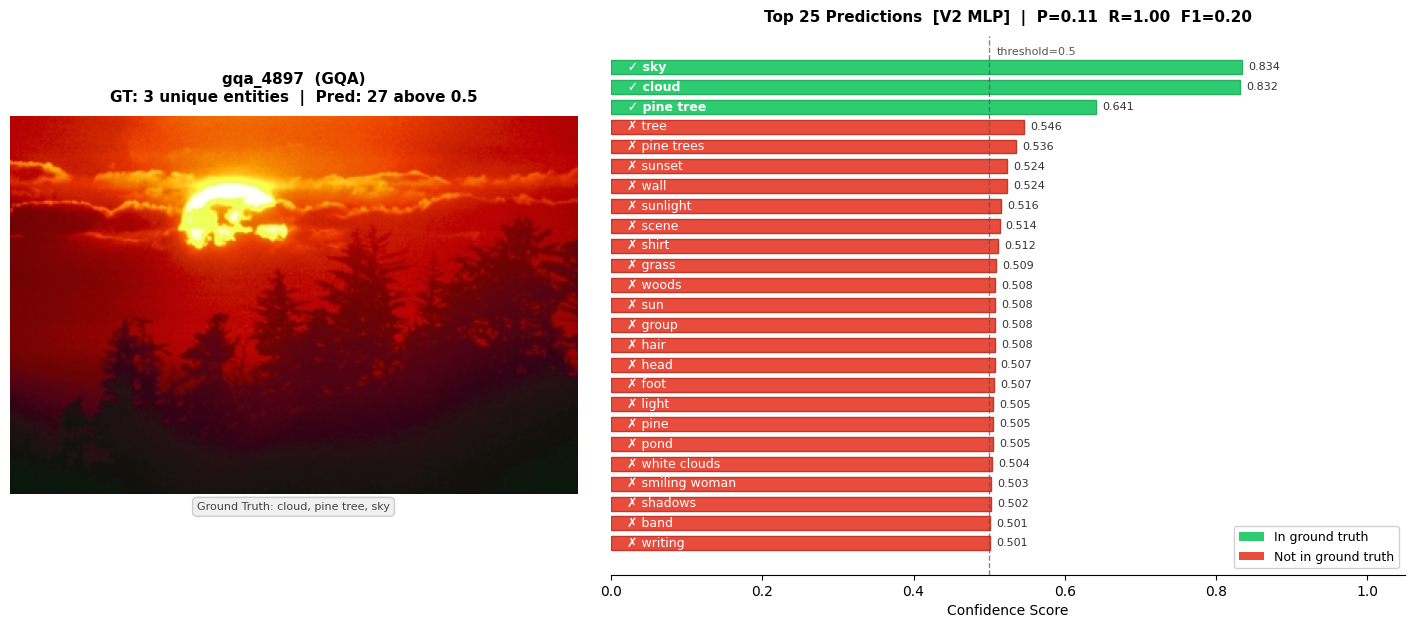

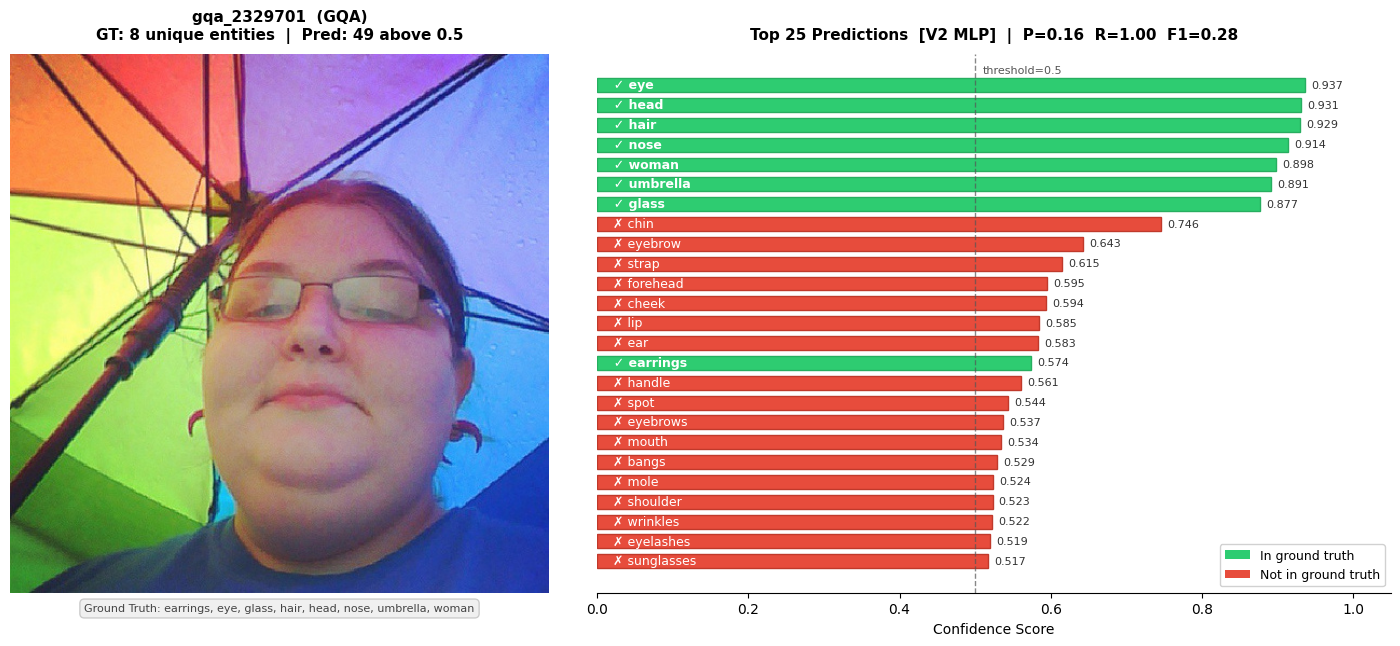

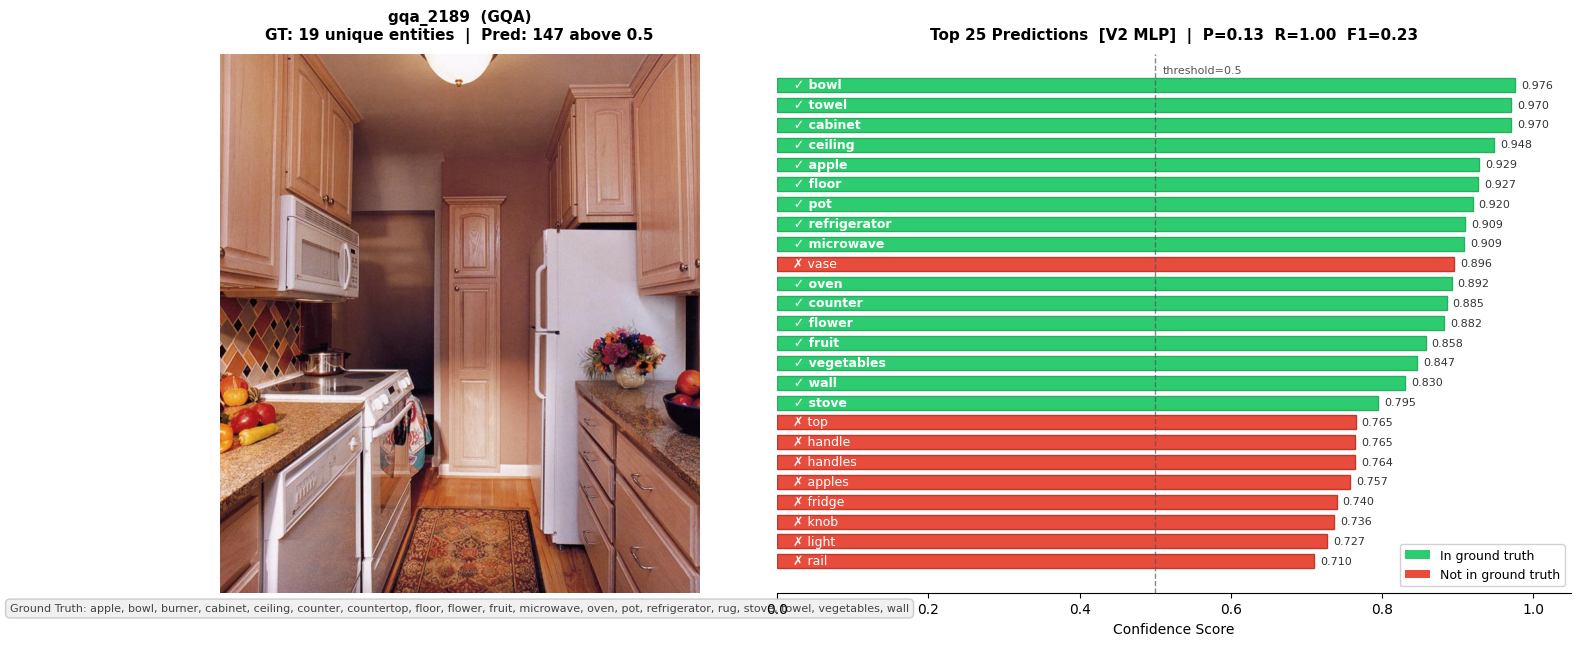

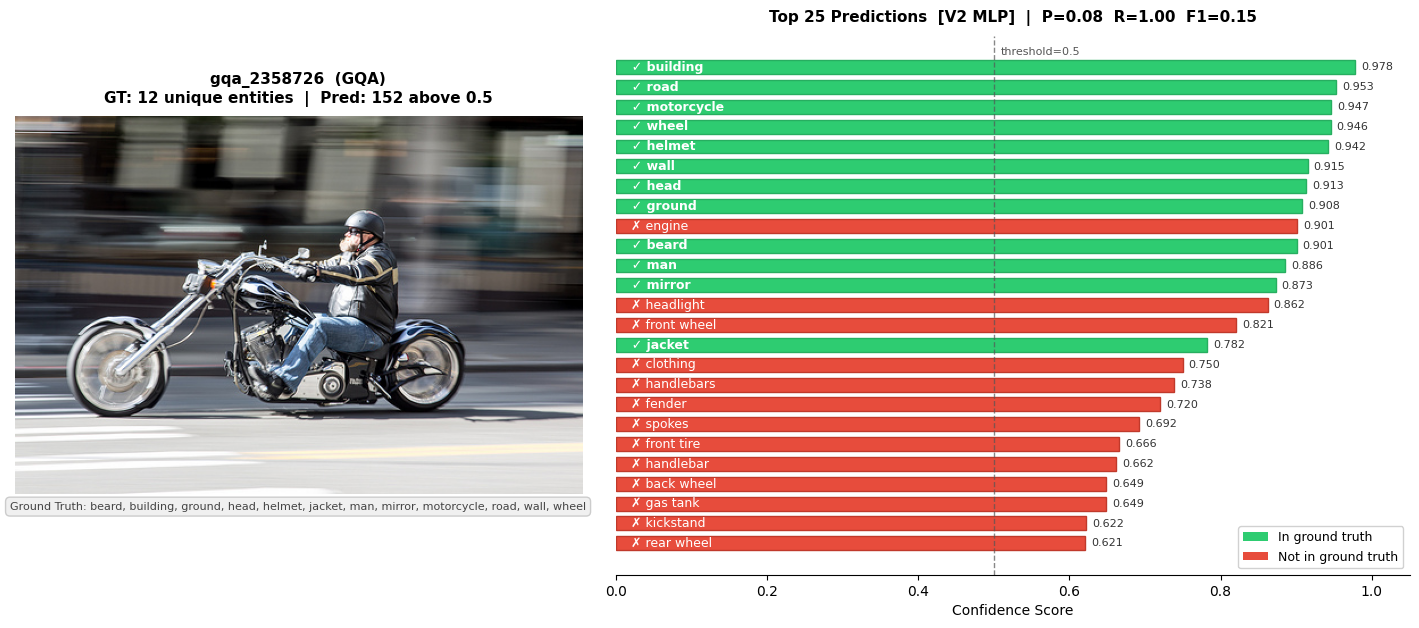

In [9]:
import json
from PIL import Image
from matplotlib.patches import Patch
from node_extractor_from_latent.utils import normalize_label

with open(cfg.val_jsonl) as f:
    val_lines = f.readlines()

NUM_VIS = 4
random.seed(42)
vis_indices = random.sample(range(len(val_lines)), NUM_VIS)

model.eval()

for sample_idx in vis_indices:
    entry         = json.loads(val_lines[sample_idx])
    gt_labels_raw = [node["label"] for node in entry["groundTruth"]["nodes"]]
    gt_labels_norm = set(normalize_label(l) for l in gt_labels_raw)

    sample_emb, _ = val_ds[sample_idx]
    with torch.no_grad():
        probs = torch.sigmoid(model(sample_emb.unsqueeze(0).to(device))).squeeze(0).cpu()

    top_k = 25
    top_scores, top_idx = torch.topk(probs, top_k)
    pred_labels = [vocab.idx_to_label[i.item()] for i in top_idx]
    pred_scores = top_scores.tolist()
    pred_hits   = [label in gt_labels_norm for label in pred_labels]

    all_preds = vocab.decode(probs, threshold=cfg.eval_threshold)
    pred_set  = set(l for l, _ in all_preds)
    tp        = len(pred_set & gt_labels_norm)
    precision = tp / len(pred_set)  if pred_set        else 0
    recall    = tp / len(gt_labels_norm) if gt_labels_norm else 0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

    fig = plt.figure(figsize=(18, 7))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.05)

    ax_img = fig.add_subplot(gs[0])
    if entry.get("image_path") and Path(entry["image_path"]).exists():
        ax_img.imshow(Image.open(entry["image_path"]))
    else:
        ax_img.text(0.5, 0.5, "Image not available", ha="center", va="center",
                    fontsize=14, transform=ax_img.transAxes)
    ax_img.set_title(
        f"{entry['id']}  ({entry['metadata']['source'].upper()})\n"
        f"GT: {len(gt_labels_norm)} unique entities  |  "
        f"Pred: {len(all_preds)} above {cfg.eval_threshold}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax_img.axis("off")
    gt_text = ", ".join(sorted(gt_labels_norm)[:20])
    if len(gt_labels_norm) > 20:
        gt_text += f"  (+{len(gt_labels_norm)-20} more)"
    ax_img.text(
        0.5, -0.02, f"Ground Truth: {gt_text}",
        ha="center", va="top", fontsize=8, color="#444",
        transform=ax_img.transAxes, wrap=True,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="#ccc"),
    )

    ax_bar = fig.add_subplot(gs[1])
    y_pos  = np.arange(top_k)[::-1]
    colors = ["#2ecc71" if h else "#e74c3c" for h in pred_hits]
    ax_bar.barh(y_pos, pred_scores, color=colors,
                edgecolor=["#27ae60" if h else "#c0392b" for h in pred_hits], height=0.7)
    ax_bar.axvline(cfg.eval_threshold, color="#555", linestyle="--", linewidth=1, alpha=0.7)
    ax_bar.text(cfg.eval_threshold + 0.01, top_k - 0.5,
                f"threshold={cfg.eval_threshold}", fontsize=8, color="#555", va="bottom")

    for i, (label, score, hit) in enumerate(zip(pred_labels, pred_scores, pred_hits)):
        marker = "\u2713" if hit else "\u2717"
        ax_bar.text(0.01, y_pos[i], f"  {marker} {label}", va="center", ha="left",
                    fontsize=9, fontweight="bold" if hit else "normal",
                    color="white" if score > 0.3 else "#333")
        ax_bar.text(score + 0.008, y_pos[i], f"{score:.3f}",
                    va="center", ha="left", fontsize=8, color="#333")

    ax_bar.set_xlim(0, 1.05); ax_bar.set_yticks([])
    ax_bar.set_xlabel("Confidence Score", fontsize=10)
    ax_bar.set_title(
        f"Top {top_k} Predictions  [V2 MLP]  |  "
        f"P={precision:.2f}  R={recall:.2f}  F1={f1:.2f}",
        fontsize=11, fontweight="bold", pad=10,
    )
    for spine in ["top", "right", "left"]:
        ax_bar.spines[spine].set_visible(False)
    ax_bar.legend(
        handles=[Patch(facecolor="#2ecc71", label="In ground truth"),
                 Patch(facecolor="#e74c3c", label="Not in ground truth")],
        loc="lower right", fontsize=9, framealpha=0.9,
    )
    plt.tight_layout()
    plt.show()
    print()